# Task 1: Data Understanding

**Import Libraries**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


**Display First Five Records**

In [5]:
df = pd.read_csv(next(iter(uploaded)))

print("Dataset Loaded Successfully")
display(df.head())

Dataset Loaded Successfully


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Identify Numerical Features**

In [6]:
print(df.select_dtypes(include=np.number).columns)

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


**Identify Categorical Features**

In [7]:
print(df.select_dtypes(include='object').columns)

Index(['Gender'], dtype='object')


**Dataset Information**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**Summary Statistics**

In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Task 2: Data Preprocessing

In [10]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


**Remove CustomerID**

In [11]:
df = df.drop("CustomerID", axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


**Encode Gender**

In [12]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


**Standardize Features**

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_data[:5]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992]])

**# Task 3: Model Development**

In [14]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

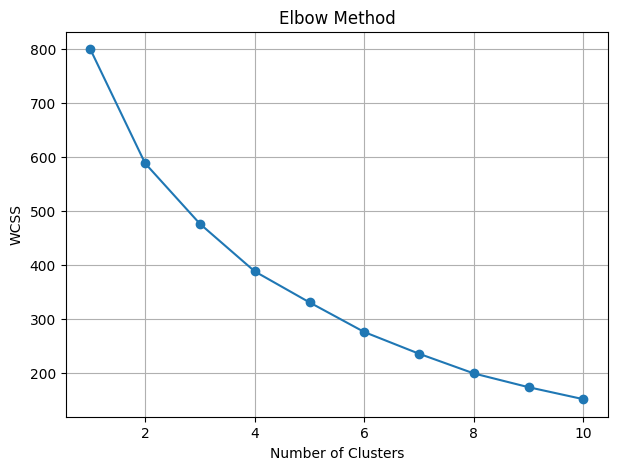

In [15]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

**Train K-Means**

In [16]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_data)

**Assign Cluster Labels**

In [17]:
df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3


**Apply PCA**

In [18]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_data)

**PCA DataFrame**

In [19]:
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


**# Task 4: Visualization and Evaluation**

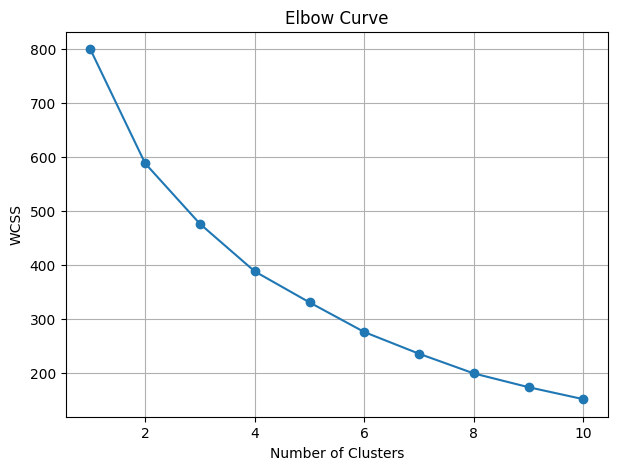

In [20]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

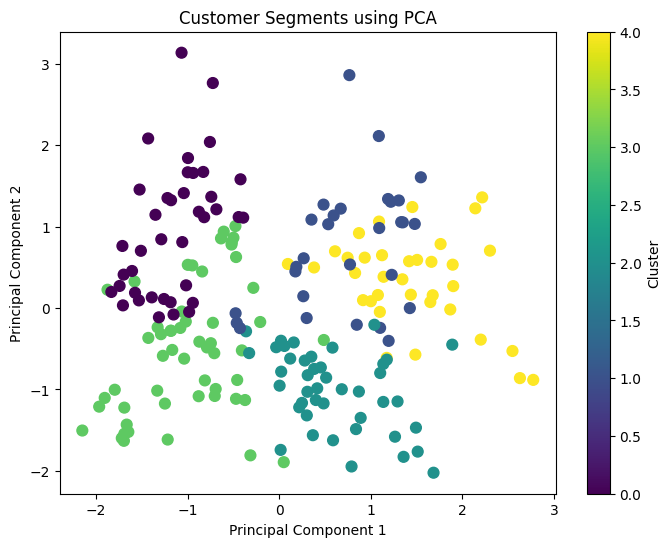

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

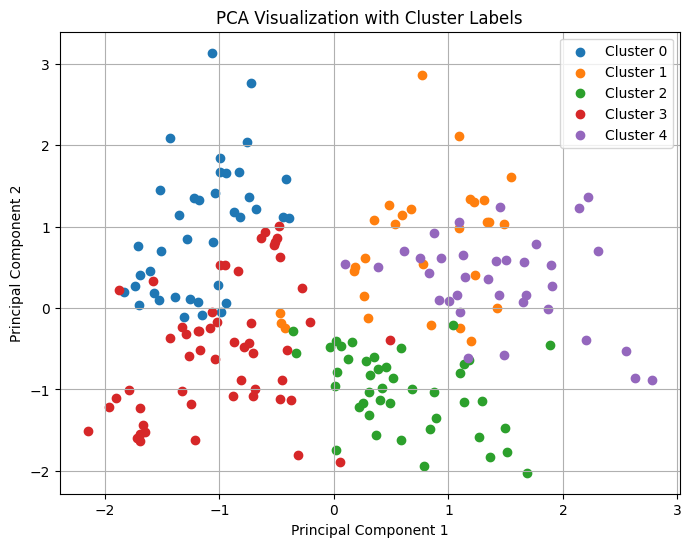

In [22]:
plt.figure(figsize=(8,6))

for i in sorted(pca_df["Cluster"].unique()):
    temp = pca_df[pca_df["Cluster"] == i]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {i}"
    )

plt.title("PCA Visualization with Cluster Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

**Observations**

## Observations

1. The Elbow Method indicates that **5 clusters** provide the optimal segmentation.

2. PCA reduces the high-dimensional dataset into two principal components, making the clusters easier to visualize.

3. The customer groups represent different spending patterns and income levels, helping businesses target specific customer segments through personalized marketing campaigns.

4. High-income and high-spending customers are ideal targets for premium offers, while low-spending customers can be engaged through discounts and loyalty programs.

**# Task 5: Conclusion**

Customer segmentation using K-Means clustering successfully divided customers into five meaningful groups based on their annual income and spending behavior. The Elbow Method identified the optimal number of clusters, while PCA reduced the multidimensional dataset into two principal components for easy visualization. These customer segments can help shopping malls design targeted marketing campaigns, improve customer satisfaction, and increase business revenue. One limitation of K-Means is that the number of clusters must be specified in advance and the algorithm is sensitive to outliers. An important advantage of PCA is that it simplifies complex datasets while preserving most of the important information, making cluster visualization and interpretation much easier.